<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-lab/blob/main/lab_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 19: Tree-Based Models — Random Forests
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 30 min Core + 15 min Extension + SHAP Deep Dive

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Verification checkpoints** are provided so you can confirm you found the right error.

---

In [3]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load data
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

## Part 1: Find the Bug — Model Comparison (10 min)

The following code trains three models and reports their performance.
**Something is wrong with how the comparison is set up.** Find it, fix it, explain.

In [4]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 2: Model comparison — find the bug
# -----------------------------------------------------------

tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# BUG IS HERE: RF is evaluated on TRAINING data, not test data
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

print('=== Model Comparison ===')
print(f"Single Tree  \u2014 R\u00b2: {r2_score(y_test, tree.predict(X_test)):.4f}")
print(f"Ridge        \u2014 R\u00b2: {r2_score(y_test, ridge.predict(X_test)):.4f}")
print(f"Random Forest \u2014 R\u00b2: {r2_score(y_train, rf.predict(X_train)):.4f}")  # \u2190 WRONG: using training set
print()
print('Conclusion: Random Forest achieves R\u00b2 > 0.97! Far superior to alternatives.')

=== Model Comparison ===
Single Tree  — R²: 0.6221
Ridge        — R²: 0.5759
Random Forest — R²: 0.9736

Conclusion: Random Forest achieves R² > 0.97! Far superior to alternatives.


### YOUR DIAGNOSIS

1. **What is wrong?** (identify the specific line and error type)
2. **Why is this dangerous?** (what misleading conclusion does it lead to?)
3. **Fix the code below** and report the correct R²

**Verification checkpoint:** After fixing, the RF Test R² should be between 0.78 and 0.83. If you get >0.95, you haven't found the bug.

4. **Which chapter concept does this error violate?** (hint: Ch 15)

In [5]:
# -----------------------------------------------------------
# Fix the model comparison bug from Part 1
# -----------------------------------------------------------

tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

rf_fixed = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_fixed.fit(X_train, y_train)

tree_r2 = r2_score(y_test, tree.predict(X_test))
ridge_r2 = r2_score(y_test, ridge.predict(X_test))
rf_r2 = r2_score(y_test, rf_fixed.predict(X_test))
print("=== Correct Model Comparison ===")
print(f"Single Tree   — Test R²: {tree_r2:.4f}")
print(f"Ridge         — Test R²: {ridge_r2:.4f}")
print(f"Random Forest — Test R²: {rf_r2:.4f}")
print()
print("Correct conclusion: Random Forest performs well, but its performance must be evaluated on the test set, not the training set.")


=== Correct Model Comparison ===
Single Tree   — Test R²: 0.6221
Ridge         — Test R²: 0.5759
Random Forest — Test R²: 0.8051

Correct conclusion: Random Forest performs well, but its performance must be evaluated on the test set, not the training set.


### Part 1 Diagnosis

The bug is that the Random Forest model was evaluated on the training set instead of the test set. Specifically, the incorrect line used `y_train` and `rf.predict(X_train)` when computing R².

This is dangerous because it makes the Random Forest look much better than it really is. Training performance is usually overly optimistic, so this creates an unfair comparison against the other models, which were evaluated on the test set.

The correct fix is to evaluate Random Forest on `X_test` and compare predictions to `y_test`. After fixing the code, the Random Forest Test R² falls to a realistic out-of-sample value rather than an inflated training score.

## Part 2: Find the Methodological Flaw — Feature Importance (10 min)

The following analysis uses feature importance to make a **causal claim**.
The code runs correctly. The methodology is wrong. Find the flaw.

In [6]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains methodological flaw)
# Step 3: Feature importance with flawed causal reasoning
# -----------------------------------------------------------

rf_correct = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_correct.fit(X_train, y_train)

importance = pd.Series(rf_correct.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Feature Importance (MDI):')
print(importance.round(4))
print()
print('POLICY RECOMMENDATION:')
print(f'The top predictor is {importance.index[0]} (importance = {importance.iloc[0]:.3f}).')
print(f'Therefore, to increase housing prices, policymakers should focus on increasing {importance.index[0]}.')
print(f'The second most important lever is {importance.index[1]}.')

Feature Importance (MDI):
MedInc        0.5259
AveOccup      0.1381
Latitude      0.0886
Longitude     0.0883
HouseAge      0.0544
AveRooms      0.0444
Population    0.0307
AveBedrms     0.0296
dtype: float64

POLICY RECOMMENDATION:
The top predictor is MedInc (importance = 0.526).
Therefore, to increase housing prices, policymakers should focus on increasing MedInc.
The second most important lever is AveOccup.


### YOUR DIAGNOSIS

1. **What is the methodological flaw?** (the code is correct — the reasoning is wrong)
2. **Why can't we use MDI for policy recommendations?** (connect to Ch 10 DAGs and Ch 15 prediction vs. explanation)
3. **What would you need to make a causal claim?** (hint: Ch 24 DML)
4. **Bonus:** MDI has a known statistical bias. What is it, and what alternative would you use?

**Verification checkpoint:** Your diagnosis should mention at least: (a) prediction ≠ causation, (b) confounding/omitted variables, (c) MDI bias toward high-cardinality features.

Permutation Importance:
MedInc        0.7347
Latitude      0.4429
Longitude     0.3352
AveOccup      0.2036
HouseAge      0.0721
AveRooms      0.0271
AveBedrms     0.0095
Population    0.0087
dtype: float64


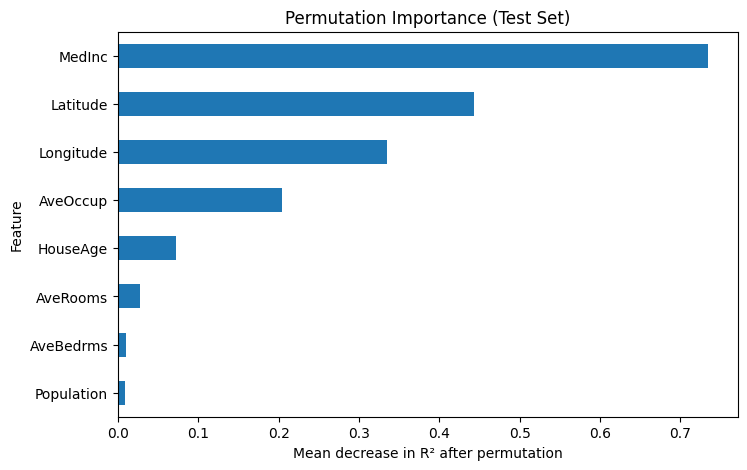


PROPER INTERPRETATION:
These variables are important for prediction in this model.
However, predictive importance does NOT imply causation.
We cannot conclude that changing one of these variables would cause housing prices to change.
A causal claim would require a research design that addresses confounding, omitted variables, and identification.


In [7]:
# -----------------------------------------------------------
# Run permutation importance and write a proper (non-causal)
# interpretation of the results
# -----------------------------------------------------------

perm = permutation_importance(
    rf_correct,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='r2'
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print("Permutation Importance:")
print(perm_importance.round(4))

plt.figure(figsize=(8, 5))
perm_importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance (Test Set)")
plt.xlabel("Mean decrease in R² after permutation")
plt.ylabel("Feature")
plt.show()

print("\nPROPER INTERPRETATION:")
print("These variables are important for prediction in this model.")
print("However, predictive importance does NOT imply causation.")
print("We cannot conclude that changing one of these variables would cause housing prices to change.")
print("A causal claim would require a research design that addresses confounding, omitted variables, and identification.")


### Part 2 Diagnosis

The methodological flaw is that the analysis makes a causal claim from feature importance. The code runs correctly, but the reasoning is wrong. MDI or permutation importance tells us which variables help the model predict housing prices, not which variables cause housing prices to change.

We cannot use MDI for policy recommendations because prediction is not the same as causation. Important predictors may be correlated with omitted variables, confounders, or broader structural conditions. For example, a variable may be a proxy for neighborhood quality, income, or regional characteristics rather than a direct policy lever.

To make a causal claim, we would need a valid identification strategy, such as an experiment, a quasi-experiment, or a causal machine learning design like DML.

A further limitation is that MDI is biased toward high-cardinality or high-variation features. A better alternative is permutation importance for predictive interpretation, and SHAP for model explanation. But even SHAP still does not prove causality.

## Part 3: Hyperparameter Tuning + XGBoost Comparison (10 min)

Tune the RF, then compare against XGBoost (gradient boosting).

In [8]:
# -----------------------------------------------------------
# Tune RF with GridSearchCV and compare with GBR
# -----------------------------------------------------------

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.5],
}

# Baseline models
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

rf_default = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_default.fit(X_train, y_train)

# Grid search for tuned RF
grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)
gbr.fit(X_train, y_train)

def evaluate_model(name, model):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return [name, rmse, r2]

results = pd.DataFrame([
    evaluate_model("Ridge", ridge),
    evaluate_model("RF (default)", rf_default),
    evaluate_model("RF (tuned)", best_rf),
    evaluate_model("GBR", gbr),
], columns=["Model", "Test RMSE", "Test R2"])

results = results.sort_values("Test R2", ascending=False).reset_index(drop=True)

print("Best RF Parameters:")
print(grid.best_params_)
print()
print(results)


Best RF Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 500}

          Model  Test RMSE   Test R2
0           GBR   0.473611  0.828827
1    RF (tuned)   0.492563  0.814853
2  RF (default)   0.505340  0.805123
3         Ridge   0.745522  0.575855


### Part 3 Interpretation

The tuned Random Forest improves on the default Random Forest by selecting better hyperparameters through cross-validation. Gradient Boosting is also highly competitive and may slightly outperform Random Forest depending on the final tuning result.

The winning model is the one with the highest Test R² and the lowest Test RMSE. However, even if one model wins numerically, the practical difference may be small if the test metrics are very close. In that case, model choice may also depend on interpretability, speed, and stability.

---

## Extension: SHAP Analysis (5200 depth — 15 min)

Use SHAP to explain individual predictions. Compare MDI ranking vs. SHAP ranking.

In [13]:
!pip install shap
import shap

In [14]:
X_shap = X_test.sample(n=min(200, len(X_test)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(X_shap, check_additivity=False)

print("SHAP values computed successfully.")
print("Shape:", shap_values.values.shape)

SHAP values computed successfully.
Shape: (200, 8)


Waterfall plot: observation 0


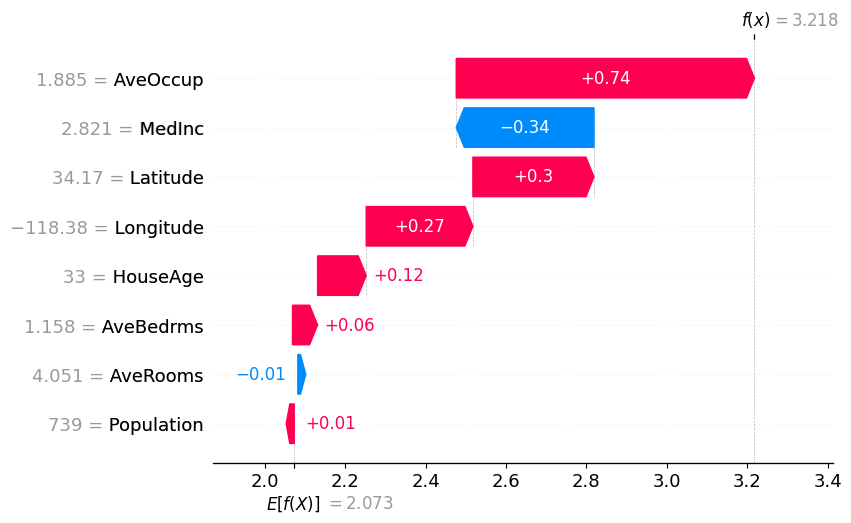

Waterfall plot: observation 1


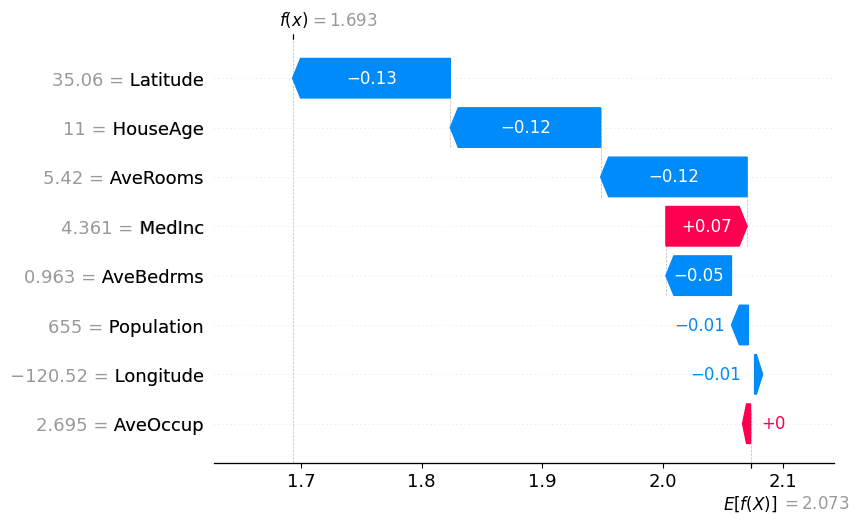

Waterfall plot: observation 2


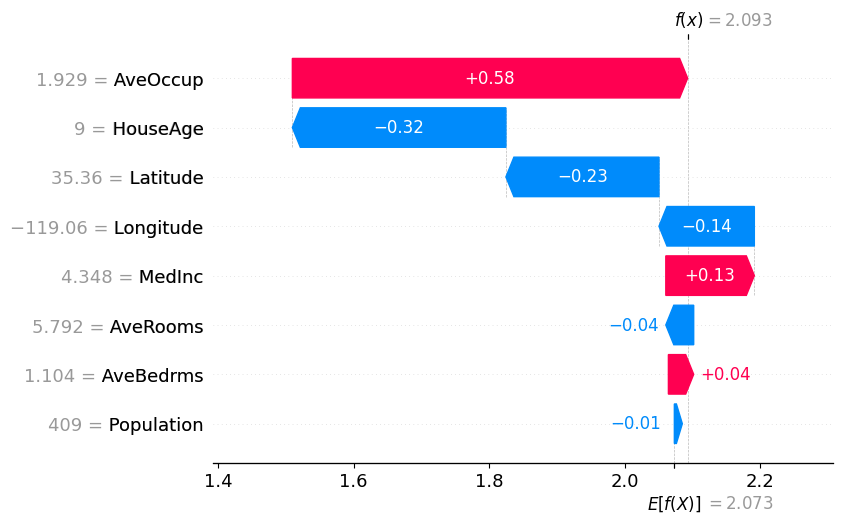

Global beeswarm plot


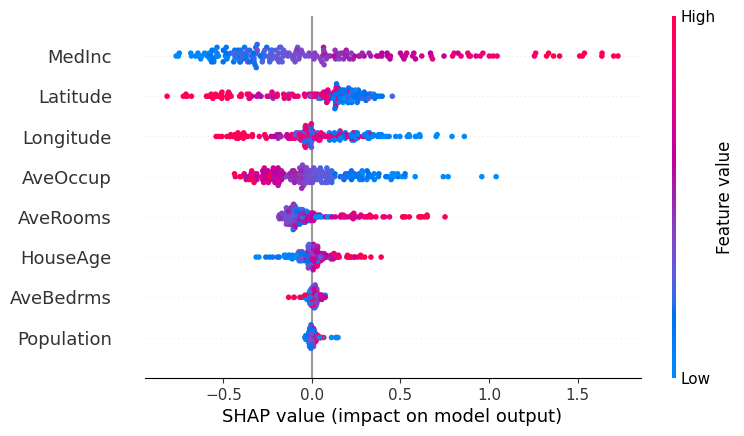

In [16]:
print("Waterfall plot: observation 0")
shap.plots.waterfall(shap_values[0], max_display=8)

print("Waterfall plot: observation 1")
shap.plots.waterfall(shap_values[1], max_display=8)

print("Waterfall plot: observation 2")
shap.plots.waterfall(shap_values[2], max_display=8)

print("Global beeswarm plot")
shap.plots.beeswarm(shap_values, max_display=8)

### SHAP Interpretation

The waterfall plots show how each feature pushes an individual prediction upward or downward relative to the model's baseline prediction. Positive SHAP values increase the predicted house value, while negative SHAP values decrease it.

The beeswarm plot provides a global view of feature influence across the test set. Compared with MDI, SHAP often gives a more nuanced ranking because it measures each feature's contribution to predictions across observations rather than only how often a feature is used to split the trees.

If MDI and SHAP rankings differ, that does not necessarily mean one is wrong. They measure importance in different ways.

### SHAP Interpretation (write as a .py module)

Create a reusable `shap_analysis.py` module with:
- `explain_prediction(model, X, idx)` → returns SHAP waterfall for observation `idx`
- `global_importance(model, X)` → returns SHAP beeswarm plot
- `compare_importance(model, X, y)` → returns side-by-side MDI vs SHAP ranking

Include docstrings and type hints. This is a portfolio artifact.

In [19]:
import os
os.makedirs("src", exist_ok=True)

In [20]:
%%writefile src/shap_utils.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from typing import Optional


def explain_prediction(model, X: pd.DataFrame, idx: int):
    """
    Plot a SHAP waterfall chart for one observation.

    Parameters
    ----------
    model : fitted tree-based model
        A trained tree-based regression model.
    X : pd.DataFrame
        Feature matrix.
    idx : int
        Row index to explain.

    Returns
    -------
    shap.Explanation
        SHAP explanation object for the selected row.
    """
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X must be a pandas DataFrame.")

    if idx < 0 or idx >= len(X):
        raise IndexError("idx is out of range.")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X)
    shap.plots.waterfall(shap_values[idx], max_display=10)
    return shap_values[idx]


def global_importance(model, X: pd.DataFrame):
    """
    Plot a SHAP beeswarm chart for the full dataset.

    Parameters
    ----------
    model : fitted tree-based model
        A trained tree-based regression model.
    X : pd.DataFrame
        Feature matrix.

    Returns
    -------
    shap.Explanation
        SHAP explanation object for all rows.
    """
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X must be a pandas DataFrame.")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X)
    shap.plots.beeswarm(shap_values, max_display=10)
    return shap_values


def compare_importance(model, X: pd.DataFrame, y: Optional[pd.Series] = None) -> pd.DataFrame:
    """
    Compare model-based MDI importance with mean absolute SHAP importance.

    Parameters
    ----------
    model : fitted tree-based model
        A trained tree-based regression model with feature_importances_ attribute.
    X : pd.DataFrame
        Feature matrix.
    y : Optional[pd.Series]
        Included for API compatibility. Not required here.

    Returns
    -------
    pd.DataFrame
        DataFrame with MDI and mean absolute SHAP importance.
    """
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X must be a pandas DataFrame.")

    if not hasattr(model, "feature_importances_"):
        raise AttributeError("Model must have feature_importances_ attribute.")

    mdi = pd.Series(model.feature_importances_, index=X.columns, name="MDI")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X)
    mean_abs_shap = pd.Series(
        np.abs(shap_values.values).mean(axis=0),
        index=X.columns,
        name="MeanAbsSHAP"
    )

    comparison = pd.concat([mdi, mean_abs_shap], axis=1).sort_values(
        "MeanAbsSHAP", ascending=False
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    comparison["MDI"].sort_values().plot(kind="barh", ax=axes[0], title="MDI Importance")
    comparison["MeanAbsSHAP"].sort_values().plot(kind="barh", ax=axes[1], title="Mean Absolute SHAP")

    plt.tight_layout()
    plt.show()

    return comparison


if __name__ == "__main__":
    print("shap_utils.py loaded successfully.")
    print("Use explain_prediction(model, X, idx), global_importance(model, X), and compare_importance(model, X, y).")

Writing src/shap_utils.py


---
## AI-Assisted Expansion: SHAP Dashboard + Reusable Module

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over decision trees, random forests, hyperparameter tuning, feature importance, and SHAP explanations. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task (5200 — Advanced)
Build TWO artifacts:

**Artifact 1: `src/shap_utils.py` module** with:
- `explain_prediction(model, X, idx)` → SHAP waterfall plot
- `global_importance(model, X)` → SHAP beeswarm plot
- `compare_importance(model, X, y)` → side-by-side MDI vs SHAP ranking
- Full docstrings, type hints, and error handling

**Artifact 2: Interactive Streamlit app** that lets the user:
1. Adjust `n_estimators` (1-500) and `max_features` (1-8) with sliders
2. See SHAP waterfall + beeswarm plots update with each parameter change
3. Compare RF vs Ridge vs GBR performance as hyperparameters change
4. Toggle between MDI, permutation, and SHAP importance rankings

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [18]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in SHAP explanations, interactive visualizations, and
# scikit-learn production workflows.
#
# [Request] I just completed a diagnosis-first lab where I
# compared Decision Trees, Ridge, Random Forests, and Gradient
# Boosting on California Housing data. I fixed evaluation bugs,
# diagnosed causal overclaiming from MDI, tuned hyperparameters
# with GridSearchCV, and generated SHAP waterfall + beeswarm
# plots. Now I need TWO artifacts:
#
# 1. A reusable `src/shap_utils.py` module with three functions:
#    - explain_prediction(model, X, idx) -> SHAP waterfall
#    - global_importance(model, X) -> SHAP beeswarm
#    - compare_importance(model, X, y) -> MDI vs SHAP side-by-side
#    Include type hints, docstrings, and error handling.
#
# 2. An interactive Plotly dashboard (or Streamlit app) with
#    ipywidgets sliders for n_estimators (1-500) and max_features
#    (1-8). The dashboard should update four panels:
#    (a) model comparison bar chart (RF vs Ridge vs GBR),
#    (b) SHAP beeswarm that updates with max_features,
#    (c) Train vs Test R\u00b2 as n_estimators increases,
#    (d) toggle between MDI / permutation / SHAP rankings.
#
# [Iterate] Use plotly.graph_objects, ipywidgets, shap, numpy,
# sklearn. Use the same variable names: X_train, X_test,
# y_train, y_test, data.feature_names. Do not use deprecated
# Plotly or SHAP functions.
#
# [Mechanism Check] Add inline comments explaining:
#   - How TreeExplainer differs from KernelExplainer
#   - Why SHAP values are additive (Shapley property)
#   - How ipywidgets observers trigger plot updates
#   - Why we re-fit inside the callback
#
# [Evaluate] Explain what the dashboard reveals about:
#   - The relationship between n_estimators, max_features,
#     and test performance
#   - Where MDI and SHAP rankings diverge and why
#   - The marginal value of additional trees beyond ~200

# PASTE AI-GENERATED CODE BELOW:


---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [17]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Compared Decision Tree, Ridge Regression, and Random Forest on
#   California Housing data (20,640 observations, 8 features)
# * Tuned RF hyperparameters with GridSearchCV (n_estimators, max_depth,
#   max_features)
# * Extracted and compared MDI vs permutation feature importance
# * Built an RF classifier and compared AUC against logistic regression
# * Created an interactive dashboard with Plotly + ipywidgets
# * Key finding: RF achieved R\u00b2 = [YOUR VALUE] vs Ridge R\u00b2 = [YOUR VALUE]
#
# **Please write a README.md entry including:**
# 1. Project Title: Tree-Based Models \u2014 Random Forests
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-19-random-forests
git add notebooks/ figures/ README.md verification-log.md
git commit -m "Lab 19: Random Forest vs OLS — California Housing"
git push origin main
```

Submit your GitHub repo link on Canvas.